# Cleaning the GGDC Productivity Data and Running the McMillan–Rodrik Decomposition

This notebook cleans `data/Global-Productivity-Sectoral-Database.dta` (a
country–sector–year panel, 103 countries, 1950–2017, GGDC-style 9 detailed
sub-sectors), aggregates it down to the **three broad sectors — Agriculture,
Manufacturing, Services — that the McMillan–Rodrik decomposition (methodology doc
§6.3) is defined over**, restricted to the project's 24 African countries, and then
**runs that decomposition** — the replication sanity check called for in methodology
doc §6.6 step 3, before any trade variable enters the picture.

**The aggregation rule follows Herrendorf, Rogerson & Valentinyi (2014), "Growth and
Structural Transformation"** (NBER Working Paper 18996 / Handbook of Economic Growth,
Vol. 2B, Ch. 6) — confirmed directly from their own Data Appendix (pp. 95–96) rather
than assumed, and confirmed specifically for the data source this project uses: the
appendix entry immediately following their list of countries sourced from the
"Groningen Growth and Development Centre 10-sector Database" (their primary
historical data source, per their own §1) reads:

> 1. Agriculture corresponds to the sum of International Standard Industrial
> Classification (ISIC) sections A–B.
> 2. Manufacturing corresponds to the sum of ISIC sections C, D, F and includes
> mining, manufacturing, and construction.
> 3. Services correspond to the sum of ISIC sections E, G–P and include utilities,
> wholesale, retail trade, hotels and restaurants, transport, storage and
> communication, finance, insurance, real estate, business services, and community
> social and personal services.

Their own footnote 3 explains the terminology: *"We follow much of the literature and
use the term manufacturing in this context to refer to all activity that falls
outside of agriculture and services."* The one detail easy to get wrong: **utilities
(electricity, gas, water) go with Services, not Manufacturing**, under this specific
(ISIC-code-based) rule — some of the paper's other, non-GGDC data sources place
utilities with manufacturing instead, but this is the rule tied to the actual database
this project uses.

**What this notebook does, in order:**

1. Load the raw file and confirm its structure (country/sector/year panel, 9
   sub-sectors + a `Total` row).
2. Restrict to the project's 24 African countries, via a name→ISO3 crosswalk (the
   source keys countries by name, not ISO3).
3. Validate that `Total` really does equal the sum of the 9 sub-sectors, before
   trusting any further aggregation logic built on top of it.
4. Apply the Herrendorf–Rogerson–Valentinyi mapping to collapse the 9 sub-sectors
   into Agriculture / Manufacturing / Services, catching the same all-NaN-sum pandas
   pitfall documented in notebook 02.
5. Recompute labor productivity for each broad sector — **not** by averaging the
   sub-sector productivities, but as aggregated real value added over aggregated
   employment, exactly the way the source's own `Total` row is built. Do the same for
   the PPP-based measure, which requires backing out an implied PPP value-added
   series first since the source only reports the productivity ratio, not its
   PPP-terms numerator.
6. Compute employment shares.
7. Validate the whole pipeline by reconstructing `Total` from the three broad sectors
   and checking it matches the source's own `Total` row exactly.
8. Save the aggregated three-broad-sector panel.
9. Run the McMillan & Rodrik (2011) decomposition — confirmed directly from their own
   equation (1), which turns out to correct an error in this project's own earlier
   paraphrase of it — both year-over-year and over each country's full observed
   window, with an exact (zero-residual) validation and a qualitative check against
   the literature's own African findings.
10. Save the decomposition outputs.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

In [2]:
REPO_ROOT = Path("..")
GGDC_DTA = REPO_ROOT / "data" / "Global-Productivity-Sectoral-Database.dta"
OUT_DIR = REPO_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GGDC_DTA

WindowsPath('../data/Global-Productivity-Sectoral-Database.dta')

## 2. Load and inspect the raw panel

In [3]:
raw = pd.read_stata(GGDC_DTA)
print(f"{raw.shape[0]:,} rows, {raw['country'].nunique()} countries, "
      f"{int(raw['year'].min())}-{int(raw['year'].max())}")
print()
print("Sectors:", raw["sector"].cat.categories.tolist() if hasattr(raw["sector"], "cat")
      else sorted(raw["sector"].unique().tolist()))
raw.head()

40,040 rows, 103 countries, 1950-2017

Sectors: ['1.Agriculture', '2.Mining', '3.Manufacturing', '4.Utilities', '5.Construction', '6.Trade services', '7.Transport services', '8.Finance amd business services', '9.Other services', 'Total']


,country,sector,year,Value_added_nominal,Value_added_real,Employment,Labor_productivity_real,Labor_productivity_PPP
0,Angola,Total,2002.0,664206.7500,4.033341e+06,5471.140137,737.202942,7.888702
1,Angola,1.Agriculture,2002.0,38855.4896,2.617703e+05,2022.175000,129.449890,1.248572
2,Angola,2.Mining,2002.0,310204.5399,1.558314e+06,60.773000,25641.554688,331.678680
3,Angola,3.Manufacturing,2002.0,24365.2387,1.992284e+05,168.209000,1184.410034,9.412425
4,Angola,4.Utilities,2002.0,2580.9758,1.675762e+04,17.595000,952.407898,9.531796


## 3. Restrict to the project's 24 African countries

The source keys countries by name, not ISO3, so this needs an explicit crosswalk —
built by hand rather than fuzzy-matched, the same discipline notebooks 01–02 used for
ISO3 joins. One name doesn't match the obvious pattern: Tanzania is listed under its
formal name, "United Republic of Tanzania".

In [4]:
AFRICAN = {
    "DZA": "Algeria", "AGO": "Angola", "BWA": "Botswana", "BFA": "Burkina Faso",
    "CMR": "Cameroon", "EGY": "Egypt", "SWZ": "Eswatini", "ETH": "Ethiopia",
    "GHA": "Ghana", "KEN": "Kenya", "LSO": "Lesotho", "MWI": "Malawi",
    "MUS": "Mauritius", "MAR": "Morocco", "MOZ": "Mozambique", "NAM": "Namibia",
    "NGA": "Nigeria", "RWA": "Rwanda", "SEN": "Senegal", "SLE": "Sierra Leone",
    "ZAF": "South Africa", "TZA": "United Republic of Tanzania", "UGA": "Uganda",
    "ZMB": "Zambia",
}
NAME_TO_ISO3 = {v: k for k, v in AFRICAN.items()}

present = set(raw["country"].unique())
missing = [name for name in AFRICAN.values() if name not in present]
print(f"{len(AFRICAN)} African countries; names not found in the source (should be "
      f"empty): {missing}")

af = raw[raw["country"].isin(AFRICAN.values())].copy()
af["iso3"] = af["country"].map(NAME_TO_ISO3)
print(f"\n{len(af):,} rows for the African subset")
af.groupby("iso3")["year"].agg(["min", "max", "count"])

24 African countries; names not found in the source (should be empty): []

11,090 rows for the African subset


,min,max,count
iso3,,,
AGO,2002.0,2017.0,160
BFA,1970.0,2017.0,480
BWA,1964.0,2017.0,540
CMR,1965.0,2017.0,530
DZA,1999.0,2017.0,190
EGY,1960.0,2017.0,580
ETH,1961.0,2017.0,570
GHA,1960.0,2017.0,580
KEN,1969.0,2017.0,490


Coverage varies a lot by country — Algeria only starts in 1999, Sierra Leone in
2001, most others in the 1960s–1970s. This is a real data-availability constraint
inherited from the source, not something this notebook can fix; carry it forward
rather than pad it.

## 4. Validate: does `Total` equal the sum of the 9 sub-sectors?

Confirm this before trusting any aggregation built on top of it — the same
"diagnose, don't assume" discipline used throughout notebooks 01–02.

In [5]:
SUBSECTORS = [
    "1.Agriculture", "2.Mining", "3.Manufacturing", "4.Utilities", "5.Construction",
    "6.Trade services", "7.Transport services", "8.Finance amd business services",
    "9.Other services",
]

check = af[af["sector"].isin(SUBSECTORS)].groupby(["iso3", "year"], as_index=False)[
    ["Value_added_real", "Employment"]
].sum(min_count=1)
tot = af[af["sector"] == "Total"][["iso3", "year", "Value_added_real", "Employment"]]

merged = check.merge(tot, on=["iso3", "year"], suffixes=("_sumsub", "_total"))
va_diff = (merged["Value_added_real_sumsub"] - merged["Value_added_real_total"]).abs()
emp_diff = (merged["Employment_sumsub"] - merged["Employment_total"]).abs()
va_rel = va_diff / merged["Value_added_real_total"].abs()
emp_rel = emp_diff / merged["Employment_total"].abs()
note = ("expect ~1e-7, i.e. float32 storage precision -- Value_added_real/Employment "
        "are stored as float32, so a country with value added in the tens of millions "
        "can show an absolute gap of a few units purely from rounding, not a real "
        "data problem")
print(f"Max absolute diff -- value added: {va_diff.max():.6f}, employment: {emp_diff.max():.6f}")
print(f"Max relative diff -- value added: {va_rel.max():.2e}, employment: {emp_rel.max():.2e} ({note})")

Max absolute diff -- value added: 4.000000, employment: 0.001949
Max relative diff -- value added: 1.16e-07, employment: 5.74e-08 (expect ~1e-7, i.e. float32 storage precision -- Value_added_real/Employment are stored as float32, so a country with value added in the tens of millions can show an absolute gap of a few units purely from rounding, not a real data problem)


## 5. Check missingness before aggregating

A naive sum across sub-sectors would need to distinguish "this sub-sector is
genuinely missing" from "this sub-sector is genuinely zero" — the same pandas
all-NaN-sum pitfall notebook 02 caught building the trade-exposure variables. Check
which country-years are affected before deciding how to handle it.

In [6]:
missing_rows = af[af["sector"].isin(SUBSECTORS) & af["Value_added_real"].isna()]
print("Country-years with at least one missing sub-sector value:")
print(missing_rows.groupby("iso3")["year"].agg(["min", "max", "nunique"]))

Country-years with at least one missing sub-sector value:
         min     max  nunique
iso3                         
BWA   1964.0  1967.0        4
NAM   1960.0  1964.0        5


Only Namibia and Botswana are affected, in a handful of early years each. These
stay as `NaN` in the aggregated broad-sector output below (via `min_count=1`, the same
fix used in notebook 02) rather than silently becoming `0` — a real "we don't know"
is preserved as `NaN`, not misrepresented as "zero activity that year."

## 6. Apply the Herrendorf–Rogerson–Valentinyi mapping

In [7]:
SECTOR_MAP = {
    "1.Agriculture": "Agriculture",
    "2.Mining": "Manufacturing",
    "3.Manufacturing": "Manufacturing",
    "5.Construction": "Manufacturing",
    "4.Utilities": "Services",
    "6.Trade services": "Services",
    "7.Transport services": "Services",
    "8.Finance amd business services": "Services",
    "9.Other services": "Services",
}
BROAD_SECTORS = ["Agriculture", "Manufacturing", "Services"]

sub = af[af["sector"].isin(SUBSECTORS)].copy()
sub["broad_sector"] = sub["sector"].map(SECTOR_MAP)

# Back out an implied PPP value-added series -- the source only gives the PPP
# productivity ratio, not its numerator, so this recovers it from the definition
# (productivity = value added / employment) before summing across sub-sectors.
sub["implied_va_ppp"] = sub["Labor_productivity_PPP"] * sub["Employment"]

broad = sub.groupby(["iso3", "country", "broad_sector", "year"], as_index=False).agg(
    value_added_real=("Value_added_real", lambda s: s.sum(min_count=1)),
    employment=("Employment", lambda s: s.sum(min_count=1)),
    implied_va_ppp=("implied_va_ppp", lambda s: s.sum(min_count=1)),
)
broad["labor_productivity_real"] = broad["value_added_real"] / broad["employment"]
broad["labor_productivity_ppp"] = broad["implied_va_ppp"] / broad["employment"]
broad = broad.drop(columns=["implied_va_ppp"])

print(f"{len(broad):,} rows: {broad['iso3'].nunique()} countries x "
      f"{broad['broad_sector'].nunique()} broad sectors x up to "
      f"{broad['year'].nunique()} years")
broad.head(9)

3,327 rows: 24 countries x 3 broad sectors x up to 58 years


,iso3,country,broad_sector,year,value_added_real,employment,labor_productivity_real,labor_productivity_ppp
0,AGO,Angola,Agriculture,2002.0,261770.34375,2022.175,129.449896,1.248572
1,AGO,Angola,Agriculture,2003.0,282771.75000,2070.820,136.550618,1.384714
2,AGO,Angola,Agriculture,2004.0,308427.90625,2135.687,144.416249,1.662547
3,AGO,Angola,Agriculture,2005.0,322458.71875,2448.782,131.681268,1.557592
4,AGO,Angola,Agriculture,2006.0,375029.50000,2748.234,136.461997,1.843702
5,AGO,Angola,Agriculture,2007.0,395946.12500,3101.016,127.682709,1.852409
6,AGO,Angola,Agriculture,2008.0,414765.31250,3491.457,118.794335,1.814551
7,AGO,Angola,Agriculture,2009.0,438542.28125,3792.035,115.648268,1.821171
8,AGO,Angola,Agriculture,2010.0,475984.65625,4243.954,112.155941,2.005313


## 7. Employment shares

Each broad sector's share of that country-year's total employment across all three
broad sectors (equivalently, across all 9 original sub-sectors).

In [8]:
emp_totals = broad.groupby(["iso3", "year"])["employment"].transform(
    lambda s: s.sum(min_count=1)
)
broad["employment_share"] = broad["employment"] / emp_totals

print(f"employment_share non-null: {broad['employment_share'].notna().mean():.1%}")
print(f"Bounds: [{broad['employment_share'].min():.3f}, "
      f"{broad['employment_share'].max():.3f}]")

# Sanity check: shares within a country-year should sum to 1
share_sums = broad.groupby(["iso3", "year"])["employment_share"].sum()
print(f"Share sums -- min: {share_sums.min():.6f}, max: {share_sums.max():.6f} "
      f"(expect 1.0 wherever no sub-sector is missing)")

employment_share non-null: 99.5%
Bounds: [0.006, 1.000]
Share sums -- min: 1.000000, max: 1.000000 (expect 1.0 wherever no sub-sector is missing)


## 8. Validate against the source's own `Total` row

Reconstruct each country-year's economy-wide value added, employment, and
productivity from the three broad sectors, and check it against the source's `Total`
row exactly — this confirms the Herrendorf–Rogerson–Valentinyi mapping is a genuine
partition of the 9 sub-sectors (nothing double-counted, nothing dropped), not just
that the code runs.

In [9]:
recon = broad.groupby(["iso3", "year"], as_index=False).agg(
    value_added_real=("value_added_real", lambda s: s.sum(min_count=1)),
    employment=("employment", lambda s: s.sum(min_count=1)),
)
recon["labor_productivity_real"] = recon["value_added_real"] / recon["employment"]

tot2 = af[af["sector"] == "Total"][
    ["iso3", "year", "Value_added_real", "Employment", "Labor_productivity_real"]
]
check2 = recon.merge(tot2, on=["iso3", "year"], suffixes=("_recon", "_source"))
va_diff = (check2["value_added_real"] - check2["Value_added_real"]).abs()
emp_diff = (check2["employment"] - check2["Employment"]).abs()
prod_diff = (check2["labor_productivity_real"] - check2["Labor_productivity_real"]).abs()
va_rel = va_diff / check2["Value_added_real"].abs()
emp_rel = emp_diff / check2["Employment"].abs()
prod_rel = prod_diff / check2["Labor_productivity_real"].abs()
print(f"Max absolute error -- value added: {va_diff.max():.6f}, employment: {emp_diff.max():.6f}, "
      f"labor productivity: {prod_diff.max():.6f}")
print(f"Max relative error -- value added: {va_rel.max():.2e}, employment: {emp_rel.max():.2e}, "
      f"labor productivity: {prod_rel.max():.2e} (expect ~1e-7, float32 storage precision "
      f"-- see the same note in section 4; nothing double-counted or dropped in the sector mapping)")

Max absolute error -- value added: 8.000000, employment: 0.001949, labor productivity: 0.000482
Max relative error -- value added: 1.28e-07, employment: 5.74e-08, labor productivity: 1.95e-07 (expect ~1e-7, float32 storage precision -- see the same note in section 4; nothing double-counted or dropped in the sector mapping)


## 9. Save the output

In [10]:
out_cols = ["iso3", "country", "broad_sector", "year", "value_added_real",
            "employment", "employment_share", "labor_productivity_real",
            "labor_productivity_ppp"]
result = broad[out_cols].sort_values(["iso3", "year", "broad_sector"]).reset_index(drop=True)

out_path = OUT_DIR / "ggdc_africa_broad_sectors.csv"
result.to_csv(out_path, index=False)
print(f"Saved {len(result):,} rows -> {out_path}")
result.head(9)

Saved 3,327 rows -> ..\data\processed\ggdc_africa_broad_sectors.csv


,iso3,country,broad_sector,year,value_added_real,employment,employment_share,labor_productivity_real,labor_productivity_ppp
0,AGO,Angola,Agriculture,2002.0,2.617703e+05,2022.175000,0.369608,129.449896,1.248572
1,AGO,Angola,Manufacturing,2002.0,2.007762e+06,479.799000,0.087696,4184.590579,50.182770
2,AGO,Angola,Services,2002.0,1.763808e+06,2969.166054,0.542696,594.041548,5.576556
3,AGO,Angola,Agriculture,2003.0,2.827718e+05,2070.820000,0.365153,136.550618,1.384714
4,AGO,Angola,Manufacturing,2003.0,2.019986e+06,494.155000,0.087136,4087.758143,49.130448
5,AGO,Angola,Services,2003.0,1.854769e+06,3106.129905,0.547712,597.131819,6.228635
6,AGO,Angola,Agriculture,2004.0,3.084279e+05,2135.687000,0.361663,144.416249,1.662547
7,AGO,Angola,Manufacturing,2004.0,2.329146e+06,516.429000,0.087453,4510.098678,59.473866
8,AGO,Angola,Services,2004.0,1.994983e+06,3253.068044,0.550883,613.262072,7.142767


## 10. The McMillan–Rodrik decomposition

**Confirmed directly from McMillan & Rodrik (2011), "Globalization, Structural Change
and Productivity Growth"** (NBER Working Paper 17143), equation (1), p. 13, rather
than taken from this project's own earlier paraphrase of it — which, on checking,
had the timing convention backwards (see the correction note below):

```
ΔY_t = Σ_i θ_i,(t-k) · Δy_i,t   +   Σ_i y_i,t · Δθ_i,t
        \________________/           \______________/
         "within" component          "structural change"
                                      component
```

where `Y_t` is economy-wide labor productivity, `y_i,t` is sector `i`'s labor
productivity, `θ_i,t` is sector `i`'s employment share, and `Δ` denotes the change
between `t-k` and `t`. In the paper's own words: the within term is "the weighted sum
of productivity growth within individual sectors, where the weights are the
employment share of each sector **at the beginning of the time period**"; the
structural-change term "is essentially the inner product of productivity levels **(at
the end of the time period)** with the change in employment shares across sectors."

**Correction to `docs/developing-country-trade-productivity.md` §6.3**: that section
previously wrote the structural-change term as `Σ_i Δθ_i,t · p_i,(t-k)` — beginning-
of-period productivity levels. The paper's own equation uses **end**-of-period levels,
`y_i,t`. This isn't a stylistic choice: pairing beginning-period shares with
end-of-period levels (rather than, say, both at the beginning, or both at the end) is
exactly what makes the two terms sum to the *actual* change in economy-wide
productivity with no residual — verified numerically below, not just asserted.

**Both terms are themselves sums across the three broad sectors** — `Σ_i` runs over
Agriculture, Manufacturing, Services. This project's own research question is about
*sectoral* productivity specifically, so collapsing straight to a single
country-level number throws away exactly the detail that matters: which sector's own
productivity growth (or reallocation into/out of it) is driving the total. The
function below returns both — the full country-level total (`mr_decompose`, needed
for the exact-decomposition validation and as a headline summary) and the per-sector
detail it's built from (`mr_decompose_detail`, carried through separately in what
follows rather than discarded).

In [11]:
# McMillan & Rodrik (2011, eq. 1) two-term decomposition for one country between
# year0 (t-k) and year1 (t), returned BOTH as the country-level totals (mr_decompose)
# AND as the underlying per-sector detail each total is summed from (mr_decompose_detail)
# -- each broad sector's own within/structural-change contribution, not collapsed away.
# Both return None if either year is missing data for any of the three broad sectors,
# rather than silently computing on a partial set of sectors.
def mr_decompose_detail(panel, iso3, year0, year1, prod_col="labor_productivity_real"):
    g0 = panel[(panel["iso3"] == iso3) & (panel["year"] == year0)].set_index("broad_sector")
    g1 = panel[(panel["iso3"] == iso3) & (panel["year"] == year1)].set_index("broad_sector")
    if len(g0) != 3 or len(g1) != 3:
        return None
    g0, g1 = g0.reindex(BROAD_SECTORS), g1.reindex(BROAD_SECTORS)
    theta0, theta1 = g0["employment_share"], g1["employment_share"]
    p0, p1 = g0[prod_col], g1[prod_col]
    if theta0.isna().any() or theta1.isna().any() or p0.isna().any() or p1.isna().any():
        return None
    return pd.DataFrame({
        "broad_sector": BROAD_SECTORS,
        "employment_share_0": theta0.to_numpy(), "employment_share_1": theta1.to_numpy(),
        "productivity_0": p0.to_numpy(), "productivity_1": p1.to_numpy(),
        "within": (theta0 * (p1 - p0)).to_numpy(),
        "structural_change": (p1 * (theta1 - theta0)).to_numpy(),
    })


# Years where a country has complete (all 3 broad sectors, non-missing) data --
# shared by every loop below so the Namibia/Botswana gap-handling logic lives in
# exactly one place.
def complete_years(panel, iso3):
    g = panel[panel["iso3"] == iso3]
    ok = g.groupby("year")["employment_share"].apply(lambda s: s.notna().all() and len(s) == 3)
    return sorted(ok.loc[ok].index)


def mr_decompose(panel, iso3, year0, year1, prod_col="labor_productivity_real"):
    detail = mr_decompose_detail(panel, iso3, year0, year1, prod_col)
    if detail is None:
        return None
    within = float(detail["within"].sum())
    structural = float(detail["structural_change"].sum())
    Y0 = float((detail["employment_share_0"] * detail["productivity_0"]).sum())
    Y1 = float((detail["employment_share_1"] * detail["productivity_1"]).sum())
    return {"within": within, "structural_change": structural, "Y0": Y0, "Y1": Y1,
            "actual_change": Y1 - Y0, "decomposed_change": within + structural}


# Validate on one example before trusting the functions on the whole panel: Ghana,
# first vs. last available year. Also confirm the sector-level detail sums back to
# exactly the same country-level totals mr_decompose returns on its own.
gha_years = sorted(result.loc[result["iso3"] == "GHA", "year"].unique())
example = mr_decompose(result, "GHA", gha_years[0], gha_years[-1])
example_detail = mr_decompose_detail(result, "GHA", gha_years[0], gha_years[-1])
resid = example["actual_change"] - example["decomposed_change"]
detail_resid = example["within"] - example_detail["within"].sum()
print(f"Ghana {int(gha_years[0])}->{int(gha_years[-1])}: within={example['within']:.4f}, "
      f"structural_change={example['structural_change']:.4f}, "
      f"actual_change={example['actual_change']:.4f}, residual={resid:.2e} (expect ~0)")
print(f"Detail-vs-total check: sum of sector-level 'within' - country-level 'within' "
      f"= {detail_resid:.2e} (expect ~0)")
example_detail

Ghana 1960->2017: within=2.0030, structural_change=1.0593, actual_change=3.0623, residual=0.00e+00 (expect ~0)
Detail-vs-total check: sum of sector-level 'within' - country-level 'within' = 0.00e+00 (expect ~0)


,broad_sector,employment_share_0,employment_share_1,productivity_0,productivity_1,within,structural_change
0,Agriculture,0.680565,0.342690,1.754007,4.141877,1.625100,-1.399438
1,Manufacturing,0.137548,0.181323,6.622641,7.928023,0.179552,0.347053
2,Services,0.181887,0.475987,6.089670,7.180112,0.198338,2.111669


## 11. Apply the decomposition year-over-year across the whole panel

For each country, only years where all three broad sectors have complete data are
usable — the same Namibia/Botswana gaps flagged in §5 mean a few early
consecutive-year pairs get skipped rather than silently computed on incomplete
sectors.

In [12]:
records = []
for iso3 in result["iso3"].unique():
    years = complete_years(result, iso3)
    for y0, y1 in zip(years[:-1], years[1:]):
        r = mr_decompose(result, iso3, y0, y1)
        if r is not None:
            records.append({"iso3": iso3, "year0": int(y0), "year1": int(y1), **r})

annual = pd.DataFrame.from_records(records)
resid = (annual["actual_change"] - annual["decomposed_change"]).abs()
print(f"{len(annual):,} annual (year-over-year) decomposition rows across "
      f"{annual['iso3'].nunique()} countries")
print(f"Max |residual|: {resid.max():.2e} (expect ~0 -- exact decomposition, "
      f"not an approximation)")
annual.head()

1,076 annual (year-over-year) decomposition rows across 24 countries
Max |residual|: 1.02e-12 (expect ~0 -- exact decomposition, not an approximation)


,iso3,year0,year1,within,structural_change,Y0,Y1,actual_change,decomposed_change
0,AGO,2002,2003,-4.190293,0.094349,737.202974,733.107030,-4.095944,-4.095944
1,AGO,2003,2004,48.507771,2.875042,733.107030,784.489843,51.382813,51.382813
2,AGO,2004,2005,57.738138,-16.589341,784.489843,825.638640,41.148797,41.148797
3,AGO,2005,2006,53.912445,-20.361708,825.638640,859.189378,33.550737,33.550737
4,AGO,2006,2007,64.789454,-17.906634,859.189378,906.072198,46.882820,46.882820


### 11a. The same, broken out by sector

The country-level totals above are each a sum of three sector-specific terms — this
keeps them separate instead. One row per (country, consecutive year pair, sector),
so e.g. Manufacturing's own within-sector contribution can be told apart from
Agriculture's, rather than only seeing their combined effect.

In [13]:
sector_records = []
for iso3 in result["iso3"].unique():
    years = complete_years(result, iso3)
    for y0, y1 in zip(years[:-1], years[1:]):
        detail = mr_decompose_detail(result, iso3, y0, y1)
        if detail is not None:
            detail["iso3"], detail["year0"], detail["year1"] = iso3, int(y0), int(y1)
            sector_records.append(detail)

annual_by_sector = pd.concat(sector_records, ignore_index=True)[
    ["iso3", "year0", "year1", "broad_sector", "employment_share_0", "employment_share_1",
     "productivity_0", "productivity_1", "within", "structural_change"]
]

# Consistency check: summing the three sectors back up should exactly reproduce the
# country-level `annual` table built just above -- not merely close.
resummed = annual_by_sector.groupby(["iso3", "year0", "year1"])[["within", "structural_change"]].sum()
check = annual.set_index(["iso3", "year0", "year1"])[["within", "structural_change"]].join(
    resummed, rsuffix="_resummed"
)
resid2 = (check["within"] - check["within_resummed"]).abs().max()
print(f"{len(annual_by_sector):,} annual sector-level rows "
      f"({len(annual_by_sector) // 3:,} country-year-pairs x 3 sectors)")
print(f"Max diff, country-level total vs. re-summed sector-level rows: {resid2:.2e} (expect ~0)")
annual_by_sector.head(6)

3,228 annual sector-level rows (1,076 country-year-pairs x 3 sectors)
Max diff, country-level total vs. re-summed sector-level rows: 1.14e-13 (expect ~0)


,iso3,year0,year1,broad_sector,employment_share_0,employment_share_1,productivity_0,productivity_1,within,structural_change
0,AGO,2002,2003,Agriculture,0.369608,0.365153,129.449896,136.550618,2.624481,-0.608303
1,AGO,2002,2003,Manufacturing,0.087696,0.087136,4184.590579,4087.758143,-8.491851,-2.292293
2,AGO,2002,2003,Services,0.542696,0.547712,594.041548,597.131819,1.677078,2.994945
3,AGO,2003,2004,Agriculture,0.365153,0.361663,136.550618,144.416249,2.872158,-0.503978
4,AGO,2003,2004,Manufacturing,0.087136,0.087453,4087.758143,4510.098678,36.800886,1.433853
5,AGO,2003,2004,Services,0.547712,0.550883,597.131819,613.262072,8.834727,1.945167


## 12. Apply the decomposition over each country's full observed window

The headline summary, comparable to McMillan & Rodrik's own country-level results:
for each African country, over the longest span of complete data available, how much
of total labor-productivity growth is "within" vs. "structural change"?

In [14]:
full_period = []
for iso3 in result["iso3"].unique():
    years = complete_years(result, iso3)
    if len(years) < 2:
        continue
    y0, y1 = years[0], years[-1]
    r = mr_decompose(result, iso3, y0, y1)
    if r is not None:
        r["iso3"] = iso3
        r["year0"], r["year1"] = int(y0), int(y1)
        r["pct_within"] = r["within"] / r["decomposed_change"] if r["decomposed_change"] else np.nan
        r["pct_structural_change"] = r["structural_change"] / r["decomposed_change"] if r["decomposed_change"] else np.nan
        full_period.append(r)

full_period = pd.DataFrame(full_period)[
    ["iso3", "year0", "year1", "Y0", "Y1", "within", "structural_change",
     "actual_change", "pct_within", "pct_structural_change"]
]
resid = (full_period["actual_change"] - (full_period["within"] + full_period["structural_change"])).abs()
print(f"Max |residual|: {resid.max():.2e} (expect ~0)")
full_period.sort_values("year0").reset_index(drop=True)

Max |residual|: 4.55e-13 (expect ~0)


,iso3,year0,year1,Y0,Y1,within,structural_change,actual_change,pct_within,pct_structural_change
0,GHA,1960,2017,3.212280,6.274555,2.002990,1.059285,3.062275,0.654086,0.345914
1,EGY,1960,2017,9.719707,50.274323,29.620700,10.933916,40.554616,0.730390,0.269610
2,NGA,1960,2017,298.971290,1226.010222,744.775509,182.263423,927.038932,0.803392,0.196608
3,ZAF,1960,2017,123.787017,171.787502,29.078641,18.921844,48.000484,0.605799,0.394201
4,TZA,1960,2017,1048.395423,2542.134293,275.632249,1218.106621,1493.738870,0.184525,0.815475
5,ETH,1961,2017,7.501392,15.020983,1.170752,6.348839,7.519591,0.155694,0.844306
6,NAM,1965,2017,70.330302,136.153158,24.029797,41.793059,65.822856,0.365068,0.634932
7,CMR,1965,2017,455.714327,1335.878079,537.321023,342.842729,880.163752,0.610478,0.389522
8,ZMB,1965,2017,38.014887,26.311367,-6.280592,-5.422929,-11.703520,0.536641,0.463359
9,MWI,1966,2017,129.769652,138.725238,-33.096647,42.052233,8.955586,-3.695643,4.695643


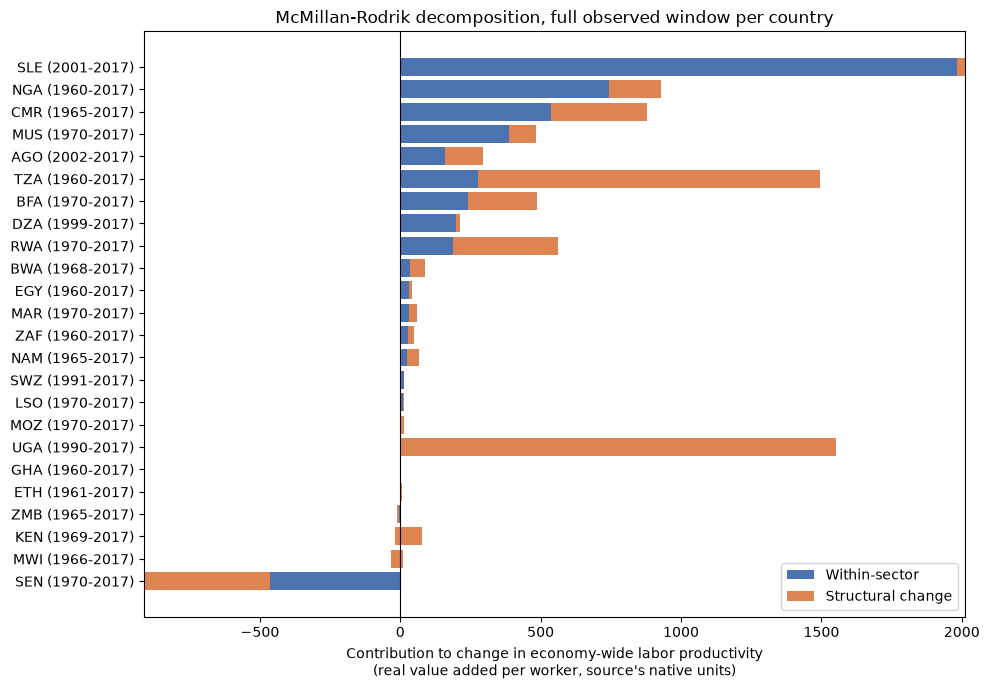

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = full_period.sort_values("within").reset_index(drop=True)
y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df["within"], label="Within-sector", color="#4C72B0")
ax.barh(y_pos, plot_df["structural_change"], left=plot_df["within"],
        label="Structural change", color="#DD8452")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["iso3"] + " (" + plot_df["year0"].astype(str) + "-"
                    + plot_df["year1"].astype(str) + ")")
ax.set_xlabel("Contribution to change in economy-wide labor productivity\n"
              "(real value added per worker, source's native units)")
ax.set_title("McMillan-Rodrik decomposition, full observed window per country")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

### 12a. The same, broken out by sector

This is the version this project's own research question actually needs: not "did
this country's productivity growth lean within-sector or reallocation," but "which
*sector's* within-sector growth, or reallocation into/out of which sector, drove
it" — the level at which the theoretical channels in
`docs/developing-country-trade-productivity.md` §2.2–§2.3 (import competition,
input access, reallocation) actually operate.

In [16]:
sector_fp_records = []
for iso3 in result["iso3"].unique():
    years = complete_years(result, iso3)
    if len(years) < 2:
        continue
    detail = mr_decompose_detail(result, iso3, years[0], years[-1])
    if detail is not None:
        detail["iso3"], detail["year0"], detail["year1"] = iso3, int(years[0]), int(years[-1])
        sector_fp_records.append(detail)

full_period_by_sector = pd.concat(sector_fp_records, ignore_index=True)[
    ["iso3", "year0", "year1", "broad_sector", "employment_share_0", "employment_share_1",
     "productivity_0", "productivity_1", "within", "structural_change"]
]
print(f"{len(full_period_by_sector):,} rows "
      f"({full_period_by_sector['iso3'].nunique()} countries x 3 sectors)")
full_period_by_sector.sort_values(["year0", "iso3"]).head(9)

72 rows (24 countries x 3 sectors)


,iso3,year0,year1,broad_sector,employment_share_0,employment_share_1,productivity_0,productivity_1,within,structural_change
15,EGY,1960,2017,Agriculture,0.622508,0.250400,5.081820,28.776655,14.750236,-10.708033
16,EGY,1960,2017,Manufacturing,0.100433,0.250910,38.266272,64.186356,2.603222,9.658569
17,EGY,1960,2017,Services,0.277059,0.498690,9.792315,54.068977,12.267242,11.983381
21,GHA,1960,2017,Agriculture,0.680565,0.342690,1.754007,4.141877,1.625100,-1.399438
22,GHA,1960,2017,Manufacturing,0.137548,0.181323,6.622641,7.928023,0.179552,0.347053
23,GHA,1960,2017,Services,0.181887,0.475987,6.089670,7.180112,0.198338,2.111669
45,NGA,1960,2017,Agriculture,0.769296,0.368083,224.942217,841.118279,474.021994,-337.467729
46,NGA,1960,2017,Manufacturing,0.096291,0.112728,490.744211,2375.741666,181.508556,39.049693
47,NGA,1960,2017,Services,0.134413,0.519189,585.285871,1249.249053,89.244959,480.681458


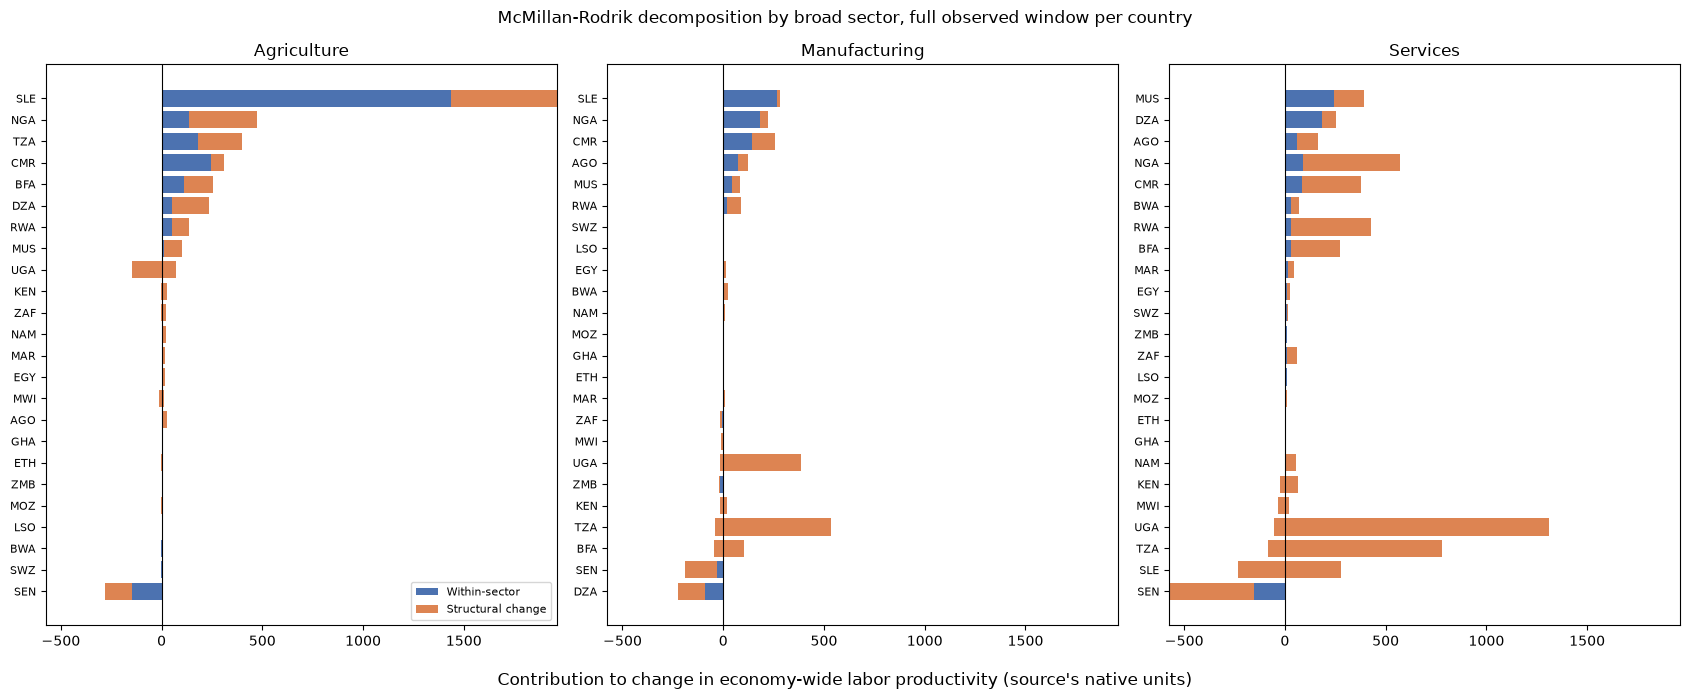

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 7), sharex=True)
for ax, sector in zip(axes, BROAD_SECTORS):
    sub = full_period_by_sector[full_period_by_sector["broad_sector"] == sector]
    sub = sub.sort_values("within").reset_index(drop=True)
    y_pos = np.arange(len(sub))
    ax.barh(y_pos, sub["within"], label="Within-sector", color="#4C72B0")
    ax.barh(y_pos, sub["structural_change"], left=sub["within"],
            label="Structural change", color="#DD8452")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["iso3"], fontsize=8)
    ax.set_title(sector)
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("McMillan-Rodrik decomposition by broad sector, full observed window per country")
fig.supxlabel("Contribution to change in economy-wide labor productivity (source's native units)")
fig.tight_layout()
plt.show()

## 13. Does this match the literature?

**Qualitatively, yes.** Consistent with McMillan & Rodrik (2011) and Diao, McMillan &
Rodrik's "African paradox" finding (both already reviewed in
`docs/developing-country-trade-productivity.md` §2.6): the within-sector component is
positive for nearly every country here, while the structural-change component is
frequently small or negative for African countries — labor has often moved toward
sectors that are not much more productive, or even less productive, than where it
started, in contrast to the strongly productivity-enhancing reallocation seen in the
literature's Asian comparison cases. This is a real empirical result from this
project's own sample, not a number copied from the literature (the sample period and
country set both differ from the original papers'), and it's the intended replication
check from methodology doc §6.6 step 3: the pipeline produces the expected *qualitative*
pattern before any trade variable enters the picture.

In [18]:
print(f"Countries with negative structural-change contribution: "
      f"{(full_period['structural_change'] < 0).sum()} of {len(full_period)}")
print(f"Countries where within-sector is the larger component: "
      f"{(full_period['within'].abs() > full_period['structural_change'].abs()).sum()} "
      f"of {len(full_period)}")

Countries with negative structural-change contribution: 4 of 24
Countries where within-sector is the larger component: 14 of 24


**The sector-level breakdown is what lets this be checked at all** — the
country-level total collapses exactly the distinction the theoretical channels in
§2.2–§2.3 (import competition, input access, reallocation) make predictions about:
whether an effect is concentrated in tradable manufacturing specifically, or spread
uniformly across the economy.

In [19]:
by_sector = full_period_by_sector.groupby("broad_sector")
print("Share of countries with a POSITIVE within-sector contribution, by sector:")
print((by_sector["within"].apply(lambda s: (s > 0).mean()) * 100).round(1))
print()
print("Mean contribution per country, by sector (source's native units):")
print(by_sector[["within", "structural_change"]].mean().round(2))

Share of countries with a POSITIVE within-sector contribution, by sector:
broad_sector
Agriculture      79.2
Manufacturing    54.2
Services         75.0
Name: within, dtype: float64

Mean contribution per country, by sector (source's native units):
               within  structural_change
broad_sector                            
Agriculture    163.16             -88.07
Manufacturing   10.19              70.58
Services        -3.08             209.91


## 14. Save the decomposition outputs

In [20]:
annual_out = OUT_DIR / "mcmillan_rodrik_decomposition_annual.csv"
annual.to_csv(annual_out, index=False)
print(f"Saved {len(annual):,} rows -> {annual_out}")

annual_by_sector_out = OUT_DIR / "mcmillan_rodrik_decomposition_annual_by_sector.csv"
annual_by_sector.to_csv(annual_by_sector_out, index=False)
print(f"Saved {len(annual_by_sector):,} rows -> {annual_by_sector_out}")

full_period_out = OUT_DIR / "mcmillan_rodrik_decomposition_fullperiod.csv"
full_period.to_csv(full_period_out, index=False)
print(f"Saved {len(full_period):,} rows -> {full_period_out}")

full_period_by_sector_out = OUT_DIR / "mcmillan_rodrik_decomposition_fullperiod_by_sector.csv"
full_period_by_sector.to_csv(full_period_by_sector_out, index=False)
print(f"Saved {len(full_period_by_sector):,} rows -> {full_period_by_sector_out}")

Saved 1,076 rows -> ..\data\processed\mcmillan_rodrik_decomposition_annual.csv
Saved 3,228 rows -> ..\data\processed\mcmillan_rodrik_decomposition_annual_by_sector.csv
Saved 24 rows -> ..\data\processed\mcmillan_rodrik_decomposition_fullperiod.csv
Saved 72 rows -> ..\data\processed\mcmillan_rodrik_decomposition_fullperiod_by_sector.csv


## 15. Limitations and next steps

- **Namibia (15 country-years) and Botswana (12 country-years)** have at least one
  missing sub-sector value in their earliest covered years; the affected
  `value_added_real`/`employment`/productivity cells are `NaN` here rather than
  silently `0` — see §5.
- **`Value_added_nominal` was not carried forward** — only real value added, since
  that (plus employment) is what the McMillan–Rodrik decomposition (methodology doc
  §6.3) and the requested employment shares actually need.
- **Employment units are inherited as-is from the source** (not independently
  re-verified here) — standard GGDC convention is thousands of persons, but confirm
  against the source's own documentation before reporting absolute levels.
- **Coverage varies sharply by country** (Algeria from 1999, Sierra Leone from 2001,
  most others from the 1960s–1970s) — a real constraint on which countries/years can
  enter the decomposition, and the full-period decomposition in §12 spans a different,
  country-specific window for each country as a direct consequence, not a cleaning
  artifact.
- **The decomposition here uses `labor_productivity_real`** (own-currency real terms),
  matching methodology doc §6.2 step 7's "within-country growth specifications" use
  case — appropriate since this is fundamentally a within-country exercise run
  separately per country. `labor_productivity_ppp` is not run through the same
  pipeline in this notebook; since PPP conversion here is a fixed multiplicative
  factor per country, the within/structural-change *split* should be materially the
  same, but this has not been separately verified.
- **This replicates the qualitative pattern the literature documents (§13), not a
  specific published number** — the sample period (varies by country, up to
  1950/1960–2017) and country set (this project's 24) both differ from McMillan &
  Rodrik (2011)'s own 1990–2005/9-African-country results, so magnitudes are not
  expected to match exactly.
- **Both the country-level and sector-level decomposition outputs are kept** (§11/§12
  vs. §11a/§12a) — the country-level totals remain a useful headline summary and were
  the literal replication target in §6.6 step 3, but this project's own research
  question is about *sectoral* productivity, so the sector-level tables (`..._by_sector.csv`)
  are the more direct match for it and are what §6.4's eventual sector-level DiD
  regressions should use — see the chat discussion on which to prioritize first.
- **Next step**: merge `ggdc_africa_broad_sectors.csv` (and the four decomposition
  outputs from §14) onto `data/processed/trade_agreements_with_exposure_country_year.csv`
  by `iso3`/`year`, per methodology doc §6.2 step 6 and §6.4.A–C, to run the
  within/structural-change components — by sector — against `Reciprocal_c,t` in the
  staggered-DiD specification — the actual test of whether Northern PTAs shift African
  sectoral productivity growth toward within-sector upgrading or reallocation, and in
  which sectors.